(lec21_live)=
# (Video) lecture 21: ML engineering "from scratch"

![ML process](https://comsc335.github.io/_images/ml_process.png)

**Our data**: [Austin Animal Center](https://www.austintexas.gov/animal-services) is the largest no-kill animal shelter in the US. 

**Question and prediction task**: The shelter wants to know, at the moment an animal walks in, which animals are at risk of a bad outcome (e.g. euthanasia, died, missing) versus a good outcome (e.g. adoption, transfer, return to owner). The goal is to help staff prioritize interventions: foster placement, medical care, or adoption listings.

We will see two new pandas concepts:

1. `pd.merge` for combining two tables on a shared key
2. Missingness with `.isna()` / `.fillna()`, plus one-hot indicators for missing categoricals


## 0. Imports

We begin with our usual imports:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data

We have two CSV files:

- `intakes.csv`, one row per animal, with information recorded at intake time (species, sex, intake type, condition, age, breed, color)
- `outcomes.csv`, one row per animal, with the outcome of their shelter stay (adopted, transferred, euthanized, etc.)

We'll need to combine them to build our dataset.


In [2]:
intakes_df = pd.read_csv("~/COMSC-335/data/intakes.csv")
outcomes_df = pd.read_csv("~/COMSC-335/data/outcomes.csv")

In [3]:
outcomes_df.head()

,Animal ID,Outcome Type
0,A704961,Adoption
1,A676160,Transfer
2,A718092,Return to Owner
3,A892519,Adoption
4,A697724,Adoption


In [4]:
intakes_df.head()

,Animal ID,Animal Type,Sex upon Intake,Intake Type,Intake Condition,Age upon Intake,Breed,Color
0,A708396,Dog,Intact Female,Stray,Normal,1 year,Pit Bull Mix,Black/White
1,A735529,Dog,Spayed Female,Stray,Normal,3 years,Labrador Retriever Mix,Brown/White
2,A762369,Cat,Spayed Female,Owner Surrender,Normal,8 years,Domestic Shorthair Mix,Brown Tabby
3,A814930,Cat,Neutered Male,Owner Surrender,Normal,3 years,Domestic Longhair Mix,Brown Tabby
4,A796971,Dog,Unknown,Stray,Normal,1 week,Labrador Retriever Mix,Brown


### New concept: `pd.merge`

Pandas has a [merge()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html) method that works like a SQL join. Given two DataFrames and a shared key column, it lines up rows that have matching keys.


In [5]:
# Toy example: left table has features, right table has labels.
left_df = pd.DataFrame({
    "id": ["A", "B", "C", "D"],
    "color": ["red", "blue", "green", "red"],
})

right_df = pd.DataFrame({
    "id": ["A", "B", "C"],
    "label": [1, 0, 1],
})

In [6]:
left_df.merge(right_df, on="id", how="left")

,id,color,label
0,A,red,1.0
1,B,blue,0.0
2,C,green,1.0
3,D,red,NaN


The `how="inner"` argument keeps only rows where the key appears in *both* tables, so that row `"D"` disappears from the output. 

The full merge options are:

- `"inner"`: keep only rows where the key appears in both tables
- `"left"`: keep all rows from the left table, and only matching rows from the right table
- `"right"`: keep all rows from the right table, and only matching rows from the left table
- `"outer"`: keep all rows from both tables, and fill missing values with `NaN`

For our shelter data we want `inner`: we only care about animals where we know both the intake info and the final outcome. Let's merge on `Animal ID`:


In [7]:
df = intakes_df.merge(outcomes_df, on="Animal ID", how="inner")

In [8]:
intakes_df.shape

(20000, 8)

## 2. Exploring the data and building our target

The merged table has the features and the labels, but our target doesn't exist as a clean binary column yet, so we have to build it. Look at the outcome column first:


In [9]:
df['Outcome Type'].value_counts(dropna=False)

Outcome Type
Adoption           9239
Transfer           5691
Return to Owner    2487
Euthanasia         1226
Died                196
Rto-Adopt           129
Disposal             90
Missing              10
NaN                   4
Relocate              2
Lost                  1
Name: count, dtype: int64

### Building the binary target

We'll call an outcome "bad" if the animal was euthanized, died, disposed of, reported missing, or lost. Everything else (adopted, transferred to a rescue, returned to owner, relocated) we'll call "good".

Like other class labels we've seen, this can be subjective! "Transferred" could mean a no-kill rescue partner (good) or another crowded facility (less good). 

:::{tip}

Pressing shift-tab in the notebook will (sometimes) show the docstring for the object under your cursor.

:::


We then need to check for missing outcome values:

In [10]:
BAD_OUTCOMES = ["Euthanasia", "Died", "Missing", "Disposal", "Lost"]

df['bad_outcome'] = df["Outcome Type"].isin(BAD_OUTCOMES).astype(int)
df['bad_outcome'].value_counts(normalize=True)

bad_outcome
0    0.920157
1    0.079843
Name: proportion, dtype: float64

<Axes: xlabel='bad_outcome', ylabel='count'>

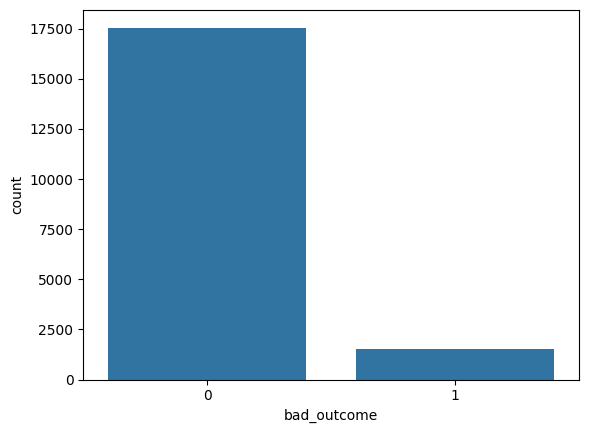

In [11]:
sns.countplot(data=df, x="bad_outcome")

:::{admonition} Class imbalance takeaway
:class: dropdown

Around 8% of animals have a bad outcome, so the classes are imbalanced. Accuracy will not be a good metric for our models, and instead we should use AUC to evaluate them.

:::

### Missingness in data

In practice, most real datasets have gaps. Pandas represents missing values as `NaN`. Two quick helpers for spotting it:

- `df.isna()` returns a boolean DataFrame the same shape as `df`, with `True` wherever a value is missing
- `df.isna().sum()` gives you a per-column count of missing values (since `True` sums as 1)

When we build `X`, we also pass `dummy_na=True` to `pd.get_dummies` so missing categoricals get explicit `_nan` columns instead of only all-zero level dummies.



In [12]:
toy_df = pd.DataFrame({
    "name":  ["Bella", "Speedy", "King"],
    "age":   [3, None, 7],
    "breed": ["Lab", "Tabby", None],
})

toy_df.isna().sum()

name     0
age      1
breed    1
dtype: int64

In [13]:
1128 / df.shape[0]

0.05913499344692005

In [14]:
df.isna().sum()

Animal ID              0
Animal Type            0
Sex upon Intake        0
Intake Type            0
Intake Condition    1128
Age upon Intake        0
Breed                  0
Color                  0
Outcome Type           4
bad_outcome            0
dtype: int64

:::{admonition} Missingness in data
:class: dropdown

Most columns are complete, but `Intake Condition` has about 1,200 missing values (~6% of rows). Here are a few reasonable choices:

- Drop the rows: okay if the missingness is random or a small fraction of the data
- Drop the column: overkill, because the non-missing rows still carry real signal
- Encode missing in the dummy expansion: adds explicit `_nan` indicator columns for categoricals with missing entries, without picking a fake string label first

Missingness itself can be an informative feature: for example, astaff member in a rush might skip the field more often for healthy-looking animals. 

:::

In [15]:
df["Intake Condition"].unique()

array(['Normal', 'Sick', 'Injured', 'Nursing', nan, 'Neonatal', 'Medical',
       'Behavior', 'Aged', 'Feral', 'Other', 'Unknown', 'Pregnant',
       'Parvo', 'Med Attn', 'Neurologic', 'Med Urgent'], dtype=object)

One last look before we build features: is `Intake Condition` actually predictive of outcome?


In [16]:
df.groupby("Intake Condition")["bad_outcome"].mean().sort_values()

Intake Condition
Behavior      0.000000
Med Attn      0.000000
Neurologic    0.000000
Parvo         0.000000
Pregnant      0.000000
Neonatal      0.042254
Normal        0.046188
Feral         0.058824
Nursing       0.062084
Medical       0.062500
Other         0.105263
Aged          0.163265
Injured       0.313351
Sick          0.380952
Med Urgent    0.500000
Unknown       0.500000
Name: bad_outcome, dtype: float64

In [17]:
df.head()

,Animal ID,Animal Type,Sex upon Intake,Intake Type,Intake Condition,Age upon Intake,Breed,Color,Outcome Type,bad_outcome
0,A708396,Dog,Intact Female,Stray,Normal,1 year,Pit Bull Mix,Black/White,Adoption,0
1,A735529,Dog,Spayed Female,Stray,Normal,3 years,Labrador Retriever Mix,Brown/White,Return to Owner,0
2,A762369,Cat,Spayed Female,Owner Surrender,Normal,8 years,Domestic Shorthair Mix,Brown Tabby,Adoption,0
3,A814930,Cat,Neutered Male,Owner Surrender,Normal,3 years,Domestic Longhair Mix,Brown Tabby,Adoption,0
4,A796971,Dog,Unknown,Stray,Normal,1 week,Labrador Retriever Mix,Brown,Transfer,0


## 3. Features and train/test split

Now we build the feature matrix `X` and label vector `y`. 

**Important:** we can only use information available at intake time.

We'll drop columns `Breed` and `Color` because they have too many unique values to use get_dummies on.

In [18]:
feature_cols = [
    'Animal Type',
    'Sex upon Intake',
    'Intake Type',
    'Intake Condition',
    'Age upon Intake',
]

X_df = df[feature_cols].copy()
y = df['bad_outcome'].copy()

### Parsing age

`Age upon Intake` is a string like `"2 years"` or `"3 weeks"`, but ML models want numbers. 

We'll write a small helper that parses any of these formats into days, then use `.apply()` to run it over the whole column:


In [19]:
df['Age upon Intake'].unique()

array(['1 year', '3 years', '8 years', '1 week', '5 months', '3 weeks',
       '4 years', '1 weeks', '1 month', '2 years', '8 months', '4 weeks',
       '6 months', '9 years', '7 months', '5 years', '10 years',
       '3 months', '2 months', '4 days', '1 day', '4 months', '13 years',
       '7 years', '11 years', '2 weeks', '6 years', '10 months', '2 days',
       '3 days', '9 months', '5 weeks', '6 days', '18 years', '17 years',
       '0 years', '19 years', '11 months', '12 years', '5 days',
       '16 years', '14 years', '15 years', '22 years'], dtype=object)

In [20]:
unit_to_days = {
    'day': 1,
    'week': 7,
    'month': 30,
    'year': 365
}

print("1 year".split())
print("years".rstrip("s"))

def parse_age(age_str: str) -> int:
    # tuple unpack the number and the unit
    num, unit = age_str.split()
    unit = unit.rstrip("s")

    return int(num) * unit_to_days[unit]

# some test cases
assert parse_age("1 year") == 365
assert parse_age("5 months") == 5 * 30

['1', 'year']
year


In [21]:
X_df["age_days"] = X_df["Age upon Intake"].apply(parse_age)
X_df = X_df.drop(columns=["Age upon Intake"])

### One-hot encoding the categorical columns

Let's look at the four categorical columns we'll use:

- `Animal Type` 
- `Sex upon Intake` 
- `Intake Type` 
- `Intake Condition`

In [22]:
categorical_cols = ["Animal Type", "Sex upon Intake", "Intake Type", "Intake Condition"]

Four categorical columns (`Animal Type`, `Sex upon Intake`, `Intake Type`, `Intake Condition`) all have a small number of observed levels, so `pd.get_dummies` can be used to generate features. We also set `dummy_na=True` so any `NaN` in those columns becomes an explicit missing-indicator column (for example `Intake Condition_nan`).


In [23]:
X_df = pd.get_dummies(X_df, categorical_cols, dummy_na=True)
X_df.head()

,age_days,Animal Type_Bird,Animal Type_Cat,Animal Type_Dog,Animal Type_Livestock,Animal Type_Other,Animal Type_nan,Sex upon Intake_Intact Female,Sex upon Intake_Intact Male,Sex upon Intake_Neutered Male,...,Intake Condition_Neonatal,Intake Condition_Neurologic,Intake Condition_Normal,Intake Condition_Nursing,Intake Condition_Other,Intake Condition_Parvo,Intake Condition_Pregnant,Intake Condition_Sick,Intake Condition_Unknown,Intake Condition_nan
0,365,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
1,1095,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,2920,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,1095,False,True,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,7,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)
print(X_test.shape)

(3815, 37)


## 4. Model, train, evaluate

### A first baseline: how far does one feature take us?

Before we use all our features at a model, let's see how well a single feature does. 

We'll fit a logistic regression on `age_days` alone and measure ROC-AUC on the test set.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe_lr_age = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr_age.fit(X_train[["age_days"]], y_train)

lr_age_scores = pipe_lr_age.predict_proba(X_test[["age_days"]])[:, 1]

In [26]:
roc_auc_score(y_test, lr_age_scores)

0.6143687824015693

### Adding all the intake features

We'll rerun the same logistic regression, but now give it every feature we built in section 3.

In [27]:
pipe_lr_all = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_lr_all.fit(X_train, y_train)

lr_all_scores = pipe_lr_all.predict_proba(X_test)[:, 1]

In [28]:
roc_auc_score(y_test, lr_all_scores)

0.906825463546775

### Another model: Random Forest


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

rf_scores = rf.predict_proba(X_test)[:, 1]

In [30]:
roc_auc_score(y_test, rf_scores)

0.9096567185091776


### Comparing all three models with ROC curves

Let's put them on one ROC plot to see the rankings side by side.


In [31]:
from sklearn.metrics import roc_curve

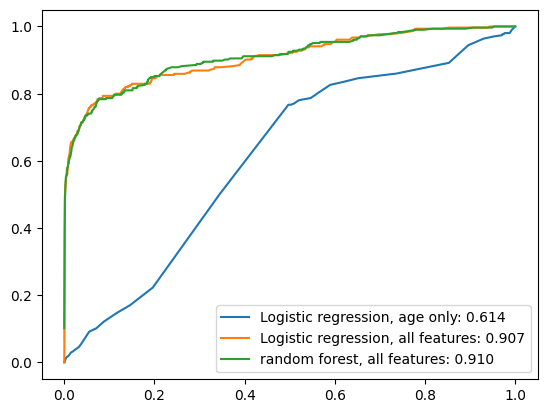

In [32]:
fig, ax = plt.subplots()

models = {
    "Logistic regression, age only": lr_age_scores,
    "Logistic regression, all features": lr_all_scores,
    "random forest, all features": rf_scores
}

for model, scores in models.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc =  roc_auc_score(y_test, scores)
    sns.lineplot(x=fpr, y=tpr, ax=ax, label=f"{model}: {auc:.3f}")

:::{admonition} feature performance takeaway
:class: dropdown

We should see a big jump from one feature to all features in the logistic regression, from about 0.60 to about 0.90. 

We see minimal improvement from the random forest. 

Getting features into a usable shape, or collecting more features, sometimes matters more than swapping the ML model type -- especially in this case where there are only a few features.

::: 


## 5. Reproducibility check

An important habit for code hygiene: every time you finish a notebook, restart the kernel and run all cells from top to bottom. This prevents:

1. **Cell-order bugs.**  Defining a variable in cell 12, then modified it in cell 5 after scrolling up. The notebook as a linear script no longer reproduces your results.
2. **Hidden randomness.** Forgetting to set `random_state` somewhere. Restart + run all lets you verify the final metric is stable across runs.

Keep `random_state=42` on every step that involves randomness to ensure reproducibility: `train_test_split`, `LogisticRegression`, `RandomForestClassifier`


We'll use **Kernel -> Restart Kernel and Run All Cells** to let the notebook rerun top to bottom.

### Wrap-up

1. Data: two raw CSVs, merged with `pd.merge` on a shared key.
2. Features: target engineering (collapsing outcome categories into binary), handling missingness, categorical encoding with `pd.get_dummies`, custom parsing for the age string.
3. Model + Train + Evaluate: three models compared on ROC-AUC: a one-feature LR, a full-feature LR, and a Random Forest.
4. Reproducibility: seeds, restart and run all, assertion on the final metric.